# Exploratory Data Analysis

In [103]:
# change directory to the repository
import os
os.chdir(r"C:\Users\mattc\OneDrive\Documents\Data\Apziva\uyBvjh22fVpcb3UX")
os.getcwd()

'C:\\Users\\mattc\\OneDrive\\Documents\\Data\\Apziva\\uyBvjh22fVpcb3UX'

In [104]:
# import all the necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
from matplotlib import pyplot as plt

In [105]:
# import the data
data = pd.read_csv("data/raw/term-deposit-marketing.csv")

In [106]:
display(Markdown('## Data Description'))

## Data Description

| Column | Description | Datatype | Type |
| :--- | :--- | :--- | :--- |
| Age | Age of customer | Numeric | Feature |
| Job | Type of job | Categorical | Feature |
| Marital | Marital status | Categorical | Feature |
| Education | Level of education | Categorical | Feature |
| Default | Has credit in default? | Binary | Feature |
| Balance | Average yearly balance (Euros) | Numeric | Feature |
| Housing | Has a housing loan? | Binary | Feature |
| Loan | Has personal loan? | Binary | Feature |
| Contact | Contact communication type | Categorical | Feature |
| Day | Last contact day of the month | Numeric | Feature |
| Month | Last contact month of year | Categorical | Feature |
| Duration | Last contact duration, in seconds | Numeric | Feature |
| Campaign | Number of contacts during this campaign | Numeric | Feature |
| Y | Has the client subscribed to a term deposit? | Binary | Target |

In [107]:
display(Markdown('## Checking Nulls and Dtypes'))

## Checking Nulls and Dtypes

In [108]:
# view the first few rows of data
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In [109]:
# view data info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


In [110]:
# changing the target column from object to numerical (binary) type
data['target'] = data['y'].map({'no': 0, 'yes': 1})
data = data.drop(columns=['y'])

In [111]:
# view data description
data.describe()

,age,balance,day,duration,campaign,target
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,40.544600,1274.277550,16.017225,254.824300,2.882175,0.072400
std,9.641776,2903.769716,8.278127,259.366498,3.239051,0.259152
min,19.000000,-8019.000000,1.000000,0.000000,1.000000,0.000000
25%,33.000000,54.000000,8.000000,100.000000,1.000000,0.000000
50%,39.000000,407.000000,17.000000,175.000000,2.000000,0.000000
75%,48.000000,1319.000000,21.000000,313.000000,3.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,1.000000


In [112]:
display(Markdown('## Assessing Outliers with Boxplots and Histograms'))

## Assessing Outliers with Boxplots and Histograms

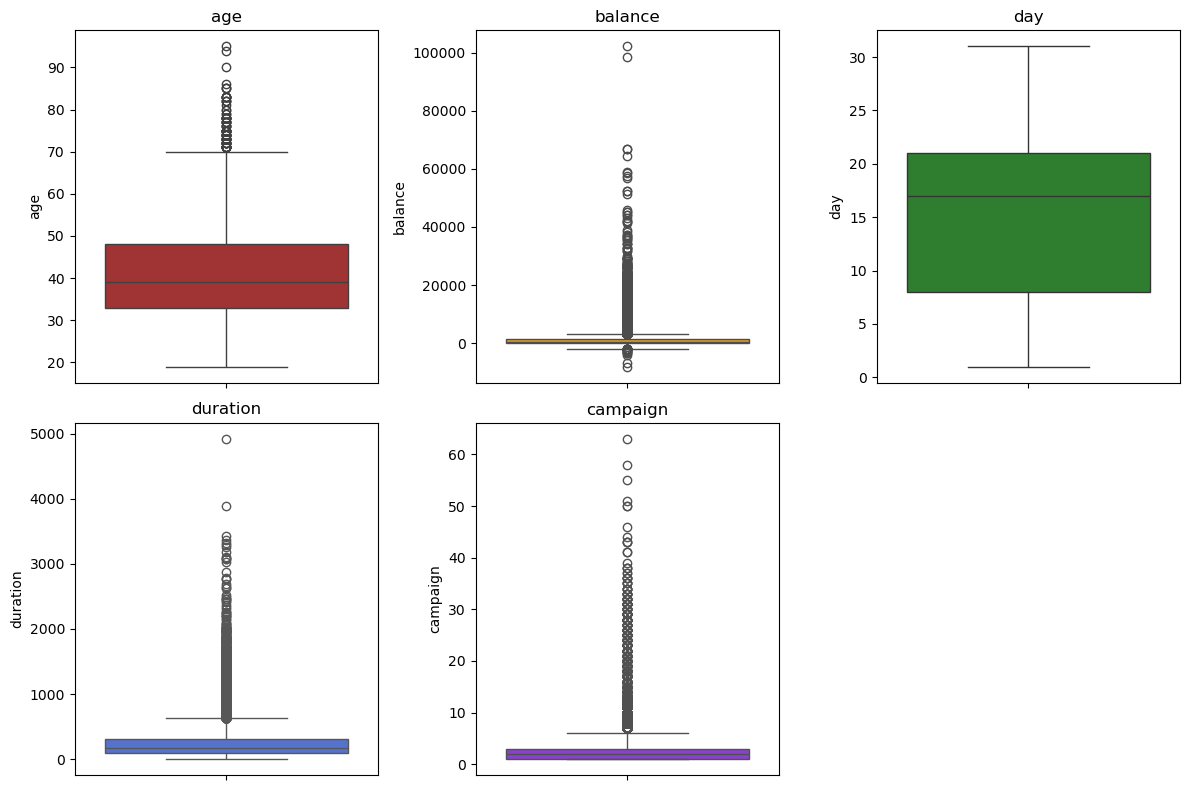

In [113]:
# plot a boxplot of each numerical column
num_data = data.select_dtypes(include='number').drop(columns=['target'])
colours = ['firebrick', 'orange', 'forestgreen', 'royalblue', 'blueviolet']

plt.figure(figsize=(12, 8))

for i in range(len(num_data.columns)):
    plt.subplot(2, 3, i+1)
    sns.boxplot(num_data.iloc[:, i], color=colours[i])
    plt.title(f'{num_data.columns[i]}')

plt.tight_layout()
plt.show()

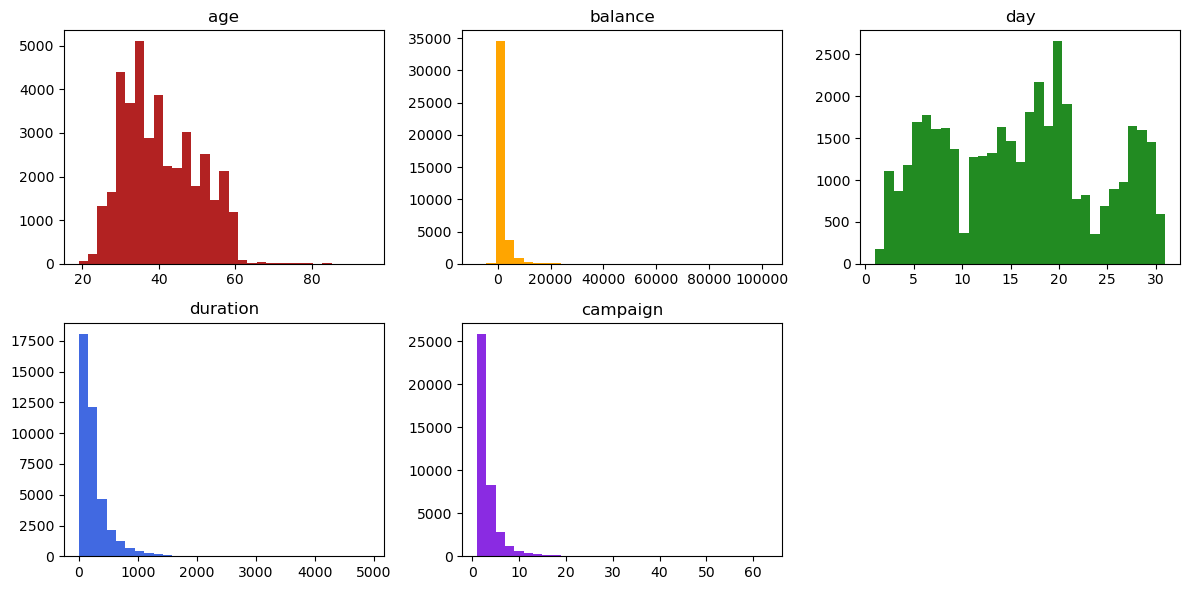

In [114]:
# plot a histogram of each numerical column
num_data = data.select_dtypes(include='number').drop(columns=['target'])
colours = ['firebrick', 'orange', 'forestgreen', 'royalblue', 'blueviolet']

plt.figure(figsize=(12, 6))

for i in range(len(num_data.columns)):
    plt.subplot(2, 3, i+1)
    plt.hist(num_data.iloc[:, i], bins=31, color=colours[i])
    plt.title(f'{num_data.columns[i]}')

plt.tight_layout()
plt.show()

In [115]:
display(Markdown('The boxplots and historgrams show that there are many outliers in the features balance, duration and campaign. For age, there is a noteable dropoff of frequency above 60.'))
display(Markdown('- **Balance:** Although the vast majority of values are below 10,000 and the highest are around 100,000, these data points are still completely plausible since this is a balance an individual could realistically have and so are considered valid. This also applies to the small number of negative values.'))
display(Markdown('- **Duration:** The most common values are around 0 to 500 seconds with some being up to 5000 seconds (83 minutes). This is a reasonable length of time for a contact and so the biggest outliers are considered valid.'))
display(Markdown('- **Campaign:** The majority of people have had less than 10 contacts, with some having over 50. This is a resonable number of contacts and so the outliers are considered valid.'))
display(Markdown('- **Age:** The highest age is 95 which is realistically possible. There is a dropoff at around 60 but there is no evidence that these data should be condidered invalid.')) 
display(Markdown("None of the outliers appear to be invalid and so they are not removed at this point. Scaling or other transformation techniques may need to be used."))

The boxplots and historgrams show that there are many outliers in the features balance, duration and campaign. For age, there is a noteable dropoff of frequency above 60.

- **Balance:** Although the vast majority of values are below 10,000 and the highest are around 100,000, these data points are still completely plausible since this is a balance an individual could realistically have and so are considered valid. This also applies to the small number of negative values.

- **Duration:** The most common values are around 0 to 500 seconds with some being up to 5000 seconds (83 minutes). This is a reasonable length of time for a contact and so the biggest outliers are considered valid.

- **Campaign:** The majority of people have had less than 10 contacts, with some having over 50. This is a resonable number of contacts and so the outliers are considered valid.

- **Age:** The highest age is 95 which is realistically possible. There is a dropoff at around 60 but there is no evidence that these data should be condidered invalid.

None of the outliers appear to be invalid and so they are not removed at this point. Scaling or other transformation techniques may need to be used.

In [116]:
display(Markdown('## Checking Target Proportions'))

## Checking Target Proportions

(0.0, 100.0)

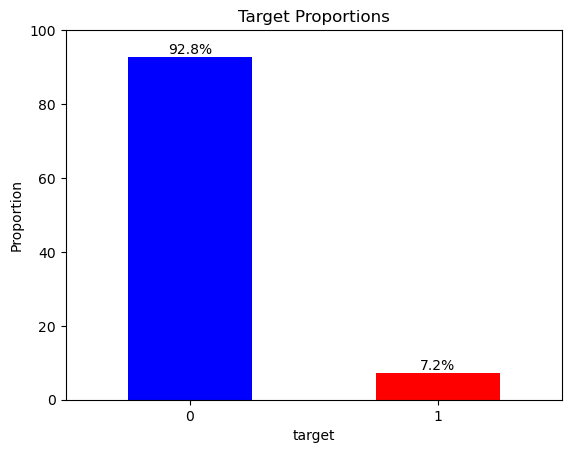

In [117]:
colours = ['blue', 'red']

target_proportions = data['target'].value_counts(normalize=True) * 100
ax = target_proportions.plot(kind='bar', color=colours)
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.xticks(rotation=0)
plt.ylabel('Proportion')
plt.title('Target Proportions')
plt.ylim(0, 100)

## Viewing Numerical Feature Correlations

<Axes: >

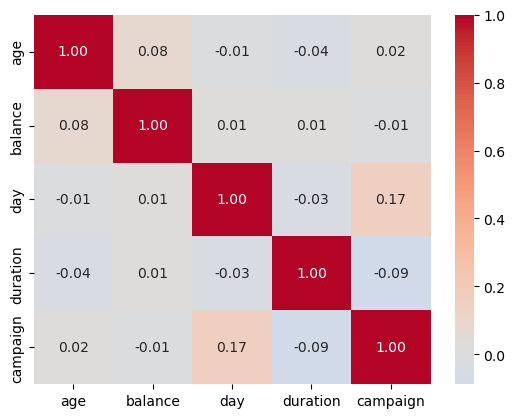

In [118]:
corr = num_data.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f')

This heatmap shows that none of the numerical features are particularly linearly correlated with each other or with the target. The greatest correlation is 0.17, between day and campaign.

## Converting Numerical Columns to Categorical

In [119]:
num_data.columns

Index(['age', 'balance', 'day', 'duration', 'campaign'], dtype='object')

In [120]:
bins = [0, 24, 34, 45, 59, 100]
labels = ['18-24', '25-34', '35-44', '45-59', '60+']

data['age_group'] = pd.cut(
    data['age'],
    bins,
    labels
)

data['age_group'].value_counts()

age_group
(34, 45]     14577
(24, 34]     12552
(45, 59]     11622
(59, 100]      727
(0, 24]        522
Name: count, dtype: int64

In [121]:
bins = [-10000, 0, 100, 200, 500, 1000, 3000, 5000, 10000, 200000]
labels = ['<0', '0-100', '100-200', '200-500', '500-1,000', '1,000-3,000', '3,000-5,000', '5,000-10,000', '10,000+']

data['balance_group'] = pd.cut(
    data['balance'], 
    bins,
    labels
)

data['balance_group'].value_counts()

balance_group
(1000, 3000]       7587
(-10000, 0]        6940
(200, 500]         6902
(500, 1000]        6056
(0, 100]           4806
(100, 200]         3083
(3000, 5000]       2281
(5000, 10000]      1674
(10000, 200000]     671
Name: count, dtype: int64

In [122]:
bins = [0, 10, 20, 31]
labels = ['early', 'mid', 'late']

data['day_group'] = pd.cut(
    data['day'],
    bins,
    labels
)

data['day_group'].value_counts()

day_group
(10, 20]    16495
(0, 10]     11781
(20, 31]    11724
Name: count, dtype: int64

In [123]:
bins = [0, 60, 120, 240, 360, 600, 900, 1200, 5000]
labels = ['0-1 min', '1-2 min', '2-4 min', '4-6 min', '6-10 min', '10-15 min', '15-20 min', '20+ min']

data['duration_group'] = pd.cut(
    data['duration'],
    bins,
    labels
)

data['duration_group'].value_counts()

duration_group
(120, 240]      12873
(60, 120]        8447
(240, 360]       6070
(360, 600]       4730
(0, 60]          4517
(600, 900]       2076
(900, 1200]       781
(1200, 5000]      503
Name: count, dtype: int64

In [124]:
bins = [0, 1, 2, 4, 6, 10, 20, 100]
labels = ['1', '2', '3-4', '5-6', '7-10', '11-20', '>20']

data['campaign_group'] = pd.cut(
    data['campaign'],
    bins,
    labels
)

data['campaign_group'].value_counts()

campaign_group
(0, 1]       14718
(1, 2]       11153
(2, 4]        8267
(4, 6]        2870
(6, 10]       1805
(10, 20]       943
(20, 100]      244
Name: count, dtype: int64

In [125]:
# converting categorical columns to dtype 'category'
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact']
for col in cat_cols:
    data[col] = data[col].astype('object')

## Viewing Categorical Feature Category Sizes and Target Proportions

# age_group

### Category Counts (%)

age_group
(34, 45]     36.4
(24, 34]     31.4
(45, 59]     29.1
(59, 100]     1.8
(0, 24]       1.3
Name: proportion, dtype: float64


### Count Plot

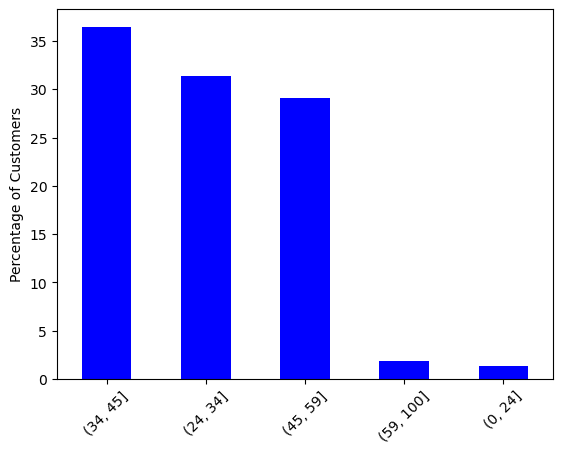

-----------------------------------------------------------------------------------------------------------------------------


# balance_group

### Category Counts (%)

balance_group
(1000, 3000]       19.0
(-10000, 0]        17.3
(200, 500]         17.3
(500, 1000]        15.1
(0, 100]           12.0
(100, 200]          7.7
(3000, 5000]        5.7
(5000, 10000]       4.2
(10000, 200000]     1.7
Name: proportion, dtype: float64


### Count Plot

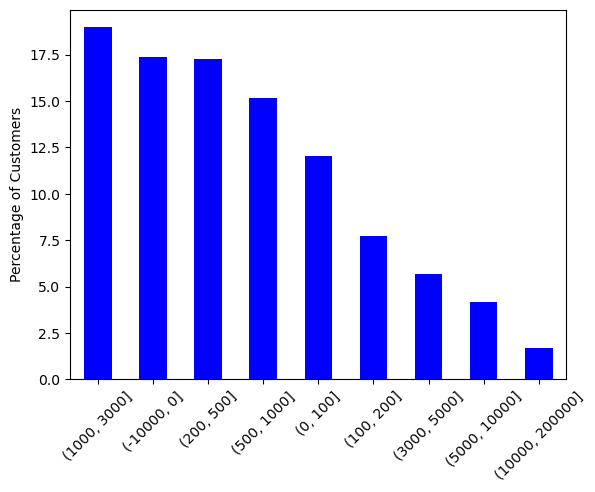

-----------------------------------------------------------------------------------------------------------------------------


# day_group

### Category Counts (%)

day_group
(10, 20]    41.2
(0, 10]     29.5
(20, 31]    29.3
Name: proportion, dtype: float64


### Count Plot

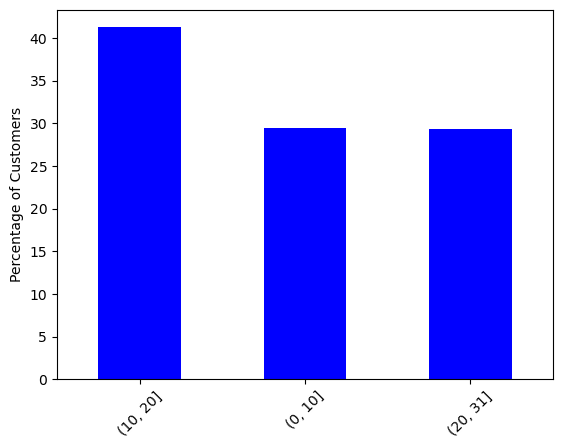

-----------------------------------------------------------------------------------------------------------------------------


# duration_group

### Category Counts (%)

duration_group
(120, 240]      32.2
(60, 120]       21.1
(240, 360]      15.2
(360, 600]      11.8
(0, 60]         11.3
(600, 900]       5.2
(900, 1200]      2.0
(1200, 5000]     1.3
Name: proportion, dtype: float64


### Count Plot

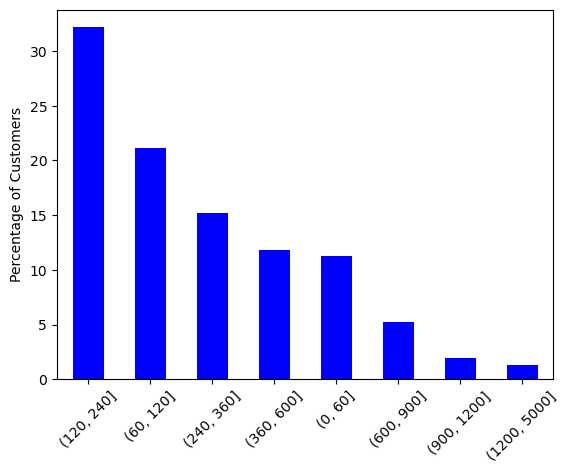

-----------------------------------------------------------------------------------------------------------------------------


# campaign_group

### Category Counts (%)

campaign_group
(0, 1]       36.8
(1, 2]       27.9
(2, 4]       20.7
(4, 6]        7.2
(6, 10]       4.5
(10, 20]      2.4
(20, 100]     0.6
Name: proportion, dtype: float64


### Count Plot

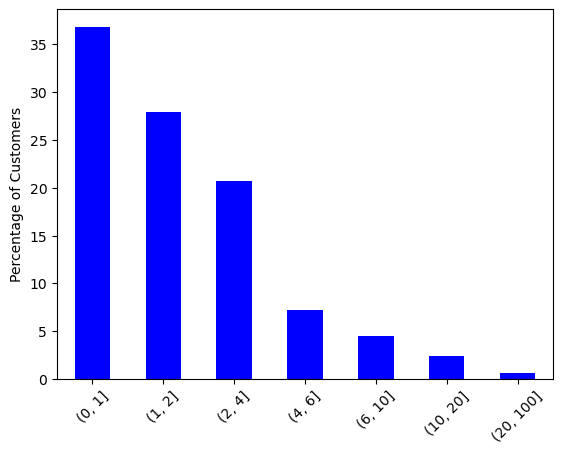

-----------------------------------------------------------------------------------------------------------------------------


In [126]:
# show the value counts of each categorical column
cat_data = data.select_dtypes(include='category')

for col in cat_data.columns:
    display(Markdown(f'# {col}'))
    display(Markdown('### Category Counts (%)'))
    print(((data[col].value_counts(normalize=True))* 100).round(1))
    display(Markdown('### Count Plot'))
    (data[col].value_counts(normalize=True)* 100).plot(kind='bar', color='blue')
    plt.xlabel('')
    plt.ylabel('Percentage of Customers')
    plt.xticks(rotation=45)
    plt.show()
    print('-----------------------------------------------------------------------------------------------------------------------------')

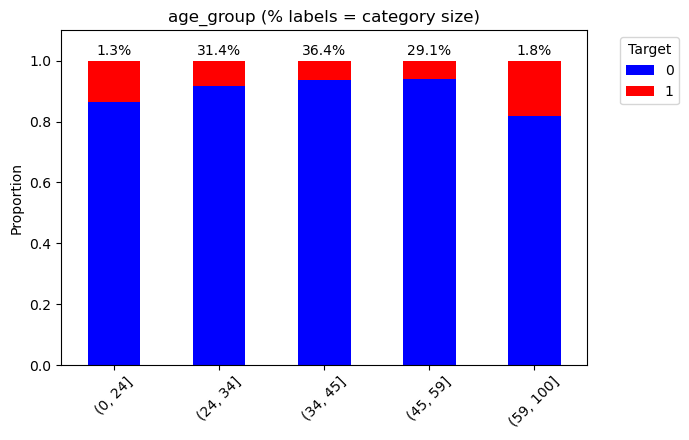

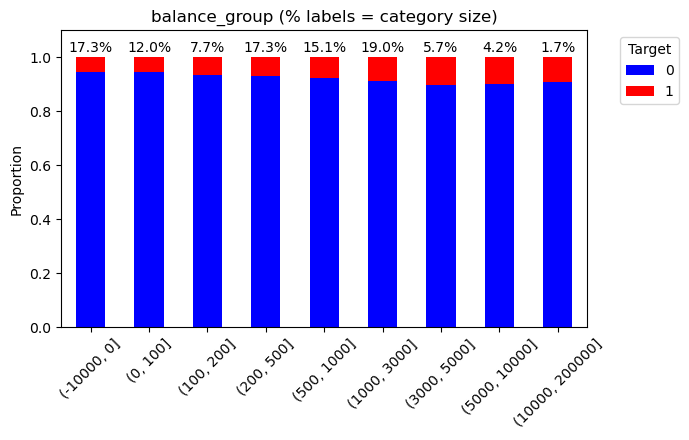

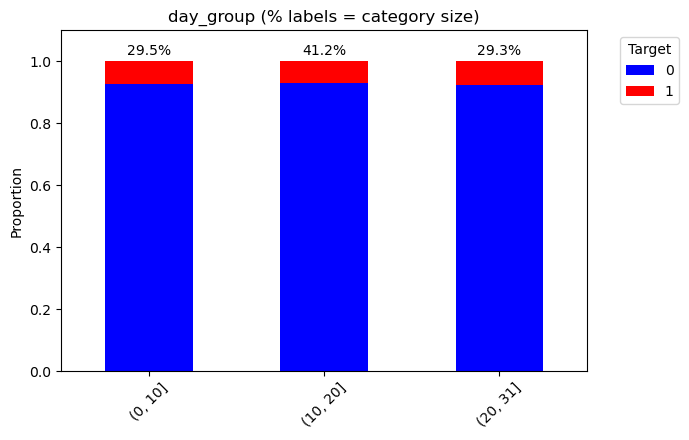

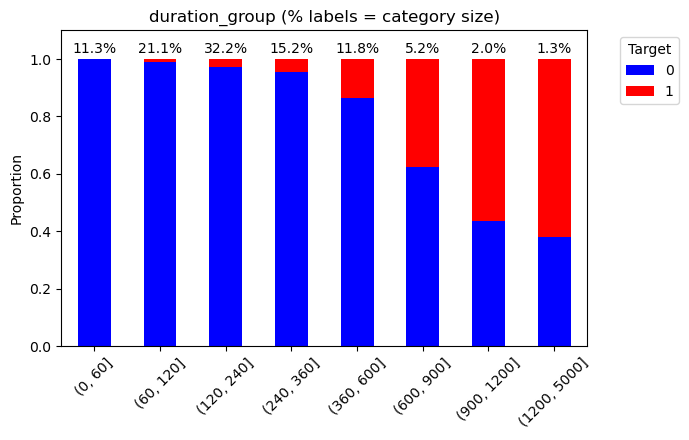

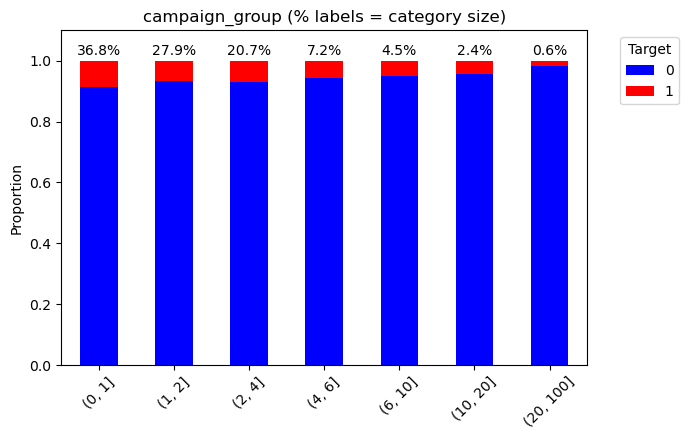

In [127]:
# show the proportion of yeses and nos of the target for each categorical feature category
cat_data = data.select_dtypes(include='category')
colours=['blue', 'red']

for col in cat_data.columns:
    crosstab = pd.crosstab(
        data[col],
        data['target'],
        normalize='index'
    )
    
    ax = crosstab.plot(
            kind='bar',
            stacked=True, 
            figsize=(7, 4.5),
            color=colours
    )

    category_percentages = data[col].value_counts(normalize=True) * 100

    for i, category in enumerate(crosstab.index):
        percentage = category_percentages[category]

        ax.text(
            i,
            1.02,
            f'{percentage:.1f}%',
            ha='center'
        )
    
    plt.title(f'{col} (% labels = category size)')
    plt.xlabel('')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.legend(
        title='Target',
        bbox_to_anchor=(1.05, 1),
        loc='upper left')
    plt.ylim(0, 1.1)
    plt.tight_layout()
    plt.show()

In [128]:
display(Markdown("The plots of target proportions for each category provide an indication of the relationship between each categorical feature and the target:"))
display(Markdown("- **Job:** The target proportions vary between job categories, although some categories contain relatively few observations, making their proportions less reliable."))
display(Markdown("- **Marital:** Single people are the most likely to subscribe while married are the least likely."))
display(Markdown("- **Education:** People with tertiary education are more likely to subscribe."))
display(Markdown("- **Default:** Little variation between the 2 categories."))
display(Markdown("- **Housing:** Those without a housing loan are slightly more likely to subscribe."))
display(Markdown("- **Loan:** Little variation between the 2 categories."))
display(Markdown("- **Contact:** Those with unknown contact type are less likely to subscribe."))
display(Markdown("- **Month:** The target proportions vary considerably between some months. However, the categories are highly uneven in size, particularly for October and December, so the proportions for these months should be interpreted with caution."))

The plots of target proportions for each category provide an indication of the relationship between each categorical feature and the target:

- **Job:** The target proportions vary between job categories, although some categories contain relatively few observations, making their proportions less reliable.

- **Marital:** Single people are the most likely to subscribe while married are the least likely.

- **Education:** People with tertiary education are more likely to subscribe.

- **Default:** Little variation between the 2 categories.

- **Housing:** Those without a housing loan are slightly more likely to subscribe.

- **Loan:** Little variation between the 2 categories.

- **Contact:** Those with unknown contact type are less likely to subscribe.

- **Month:** The target proportions vary considerably between some months. However, the categories are highly uneven in size, particularly for October and December, so the proportions for these months should be interpreted with caution.

In [129]:
data = data.drop(columns=['month'])

In [130]:
data.to_csv("data/processed/processed_data.csv", index=False)

In [131]:
data.dtypes

age                  int64
job                 object
marital             object
education           object
default             object
balance              int64
housing             object
loan                object
contact             object
day                  int64
duration             int64
campaign             int64
target               int64
age_group         category
balance_group     category
day_group         category
duration_group    category
campaign_group    category
dtype: object